In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, roc_auc_score,
                             f1_score, classification_report,
                             roc_curve)
from scipy.stats import pearsonr

os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Load data
X_train     = np.load('models/X_train.npy')
X_test      = np.load('models/X_test.npy')
y_train_reg = np.load('models/y_train_reg.npy')
y_test_reg  = np.load('models/y_test_reg.npy')
y_train_clf = np.load('models/y_train_clf.npy')
y_test_clf  = np.load('models/y_test_clf.npy')

# Load saved RF models
rf_reg = joblib.load('models/rf_regressor.pkl')
rf_clf = joblib.load('models/rf_classifier.pkl')

# Recompute RF predictions so variables exist
y_pred_rf_reg  = rf_reg.predict(X_test)
y_pred_rf_clf  = rf_clf.predict(X_test)
y_pred_rf_prob = rf_clf.predict_proba(X_test)[:, 1]
rf_auc         = roc_auc_score(y_test_clf, y_pred_rf_prob)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("All loaded. Ready.")

FileNotFoundError: [Errno 2] No such file or directory: 'models/X_train.npy'

In [2]:
import os
os.chdir(r'D:\DrugResponseProject')
print("Working directory:", os.getcwd())

Working directory: D:\DrugResponseProject


In [3]:
# ── XGBoost Regressor ────────────────────────────────────────────
print("Training XGBoost Regressor...")
xgb_reg = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    n_jobs=-1, random_state=42, verbosity=0
)
xgb_reg.fit(X_train, y_train_reg, verbose=False)
y_pred_xgb_reg       = xgb_reg.predict(X_test)
rmse_xgb             = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg))
r2_xgb               = r2_score(y_test_reg, y_pred_xgb_reg)
pearson_r_xgb, _     = pearsonr(y_test_reg, y_pred_xgb_reg)

print(f"RMSE:      {rmse_xgb:.4f}  (RF was 1.0070)")
print(f"R²:        {r2_xgb:.4f}  (RF was 0.2814)")
print(f"Pearson r: {pearson_r_xgb:.4f}  (RF was 0.5317)")

# ── XGBoost Classifier ───────────────────────────────────────────
print("\nTraining XGBoost Classifier...")
xgb_clf = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='logloss', n_jobs=-1,
    random_state=42, verbosity=0
)
xgb_clf.fit(X_train, y_train_clf, verbose=False)
y_pred_xgb_clf  = xgb_clf.predict(X_test)
y_pred_xgb_prob = xgb_clf.predict_proba(X_test)[:, 1]
acc_xgb  = accuracy_score(y_test_clf, y_pred_xgb_clf)
auc_xgb  = roc_auc_score(y_test_clf, y_pred_xgb_prob)
f1_xgb   = f1_score(y_test_clf, y_pred_xgb_clf)

print(f"Accuracy:  {acc_xgb*100:.1f}%  (RF was 62.0%)")
print(f"AUC-ROC:   {auc_xgb:.4f}  (RF was 0.6825)")
print(f"F1:        {f1_xgb:.4f}  (RF was 0.6344)")
print(classification_report(y_test_clf, y_pred_xgb_clf,
                             target_names=['Resistant','Sensitive']))

# ── Plot 10: Regression comparison ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, y_pred, title, r, r2 in zip(
    axes,
    [y_pred_rf_reg, y_pred_xgb_reg],
    ['Random Forest', 'XGBoost'],
    [0.5317, pearson_r_xgb],
    [0.2814, r2_xgb]
):
    ax.scatter(y_test_reg, y_pred, alpha=0.5, s=25,
               color='steelblue', edgecolors='none')
    mn = min(y_test_reg.min(), y_pred.min())
    mx = max(y_test_reg.max(), y_pred.max())
    ax.plot([mn,mx],[mn,mx],'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Actual LN_IC50', fontsize=12)
    ax.set_ylabel('Predicted LN_IC50', fontsize=12)
    ax.set_title(f'{title}\nPearson r={r:.3f} | R²={r2:.3f}', fontsize=12)
    ax.legend(fontsize=10)
plt.suptitle('Regression Comparison — Erlotinib IC50',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/plot10_xgb_vs_rf_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 10 saved.")

# ── Plot 11: ROC comparison ───────────────────────────────────────
fpr_rf,  tpr_rf,  _ = roc_curve(y_test_clf, y_pred_rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_clf, y_pred_xgb_prob)
plt.figure(figsize=(8, 7))
plt.plot(fpr_rf,  tpr_rf,  color='steelblue',  linewidth=2.5,
         label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', linewidth=2.5,
         label=f'XGBoost       (AUC = {auc_xgb:.3f})')
plt.plot([0,1],[0,1],'k--', linewidth=1.5, label='Random guess (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve — Random Forest vs XGBoost\nErlotinib Sensitivity', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/plot11_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 11 saved.")

# ── Plot 12: XGBoost feature importance ──────────────────────────
importances = xgb_clf.feature_importances_
indices     = np.argsort(importances)[::-1][:20]
plt.figure(figsize=(10, 6))
plt.bar(range(20), importances[indices],
        color='darkorange', edgecolor='white')
plt.xticks(range(20),
           [f'PC{indices[i]+1}' for i in range(20)],
           rotation=45, ha='right')
plt.xlabel('PCA Component', fontsize=12)
plt.ylabel('Feature Importance', fontsize=12)
plt.title('Top 20 Most Important PCA Components\n(XGBoost)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/plot12_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 12 saved.")

# ── Save models + update results table ───────────────────────────
joblib.dump(xgb_reg, 'models/xgb_regressor.pkl')
joblib.dump(xgb_clf, 'models/xgb_classifier.pkl')

new_rows = pd.DataFrame({
    'Model':     ['XGB Regression', 'XGB Classification'],
    'RMSE':      [round(rmse_xgb, 4),       None],
    'R2':        [round(r2_xgb, 4),         None],
    'Pearson_r': [round(pearson_r_xgb, 4),  None],
    'Accuracy':  [None, round(acc_xgb, 4)],
    'AUC_ROC':   [None, round(auc_xgb, 4)],
    'F1':        [None, round(f1_xgb, 4)]
})
results_df = pd.read_csv('models/model_results.csv')
results_df = pd.concat([results_df, new_rows], ignore_index=True)
results_df.to_csv('models/model_results.csv', index=False)

print("\n=== DAY 5 COMPLETE ===")
print(results_df.to_string(index=False))

Training XGBoost Regressor...


NameError: name 'X_train' is not defined

In [1]:
import os
os.chdir(r'C:\DrugResponseProject')
print("Working directory:", os.getcwd())

Working directory: C:\DrugResponseProject


In [2]:
import os
os.chdir(r'D:\DrugResponseProject')
print("Working directory:", os.getcwd())

Working directory: D:\DrugResponseProject


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, roc_auc_score,
                             f1_score, classification_report,
                             roc_curve)
from scipy.stats import pearsonr

X_train     = np.load('models/X_train.npy')
X_test      = np.load('models/X_test.npy')
y_train_reg = np.load('models/y_train_reg.npy')
y_test_reg  = np.load('models/y_test_reg.npy')
y_train_clf = np.load('models/y_train_clf.npy')
y_test_clf  = np.load('models/y_test_clf.npy')

rf_reg = joblib.load('models/rf_regressor.pkl')
rf_clf = joblib.load('models/rf_classifier.pkl')

y_pred_rf_reg  = rf_reg.predict(X_test)
y_pred_rf_prob = rf_clf.predict_proba(X_test)[:, 1]
rf_auc         = roc_auc_score(y_test_clf, y_pred_rf_prob)

print("X_train:", X_train.shape)
print("All loaded. Ready.")

X_train: (712, 50)
All loaded. Ready.


Training XGBoost Regressor...
RMSE:      1.0321  (RF was 1.0070)
R²:        0.2452  (RF was 0.2814)
Pearson r: 0.5059  (RF was 0.5317)

Training XGBoost Classifier...
Accuracy:  65.4%  (RF was 62.0%)
AUC-ROC:   0.6918  (RF was 0.6825)
F1:        0.6630  (RF was 0.6344)
              precision    recall  f1-score   support

   Resistant       0.67      0.62      0.64        90
   Sensitive       0.64      0.69      0.66        89

    accuracy                           0.65       179
   macro avg       0.65      0.65      0.65       179
weighted avg       0.65      0.65      0.65       179



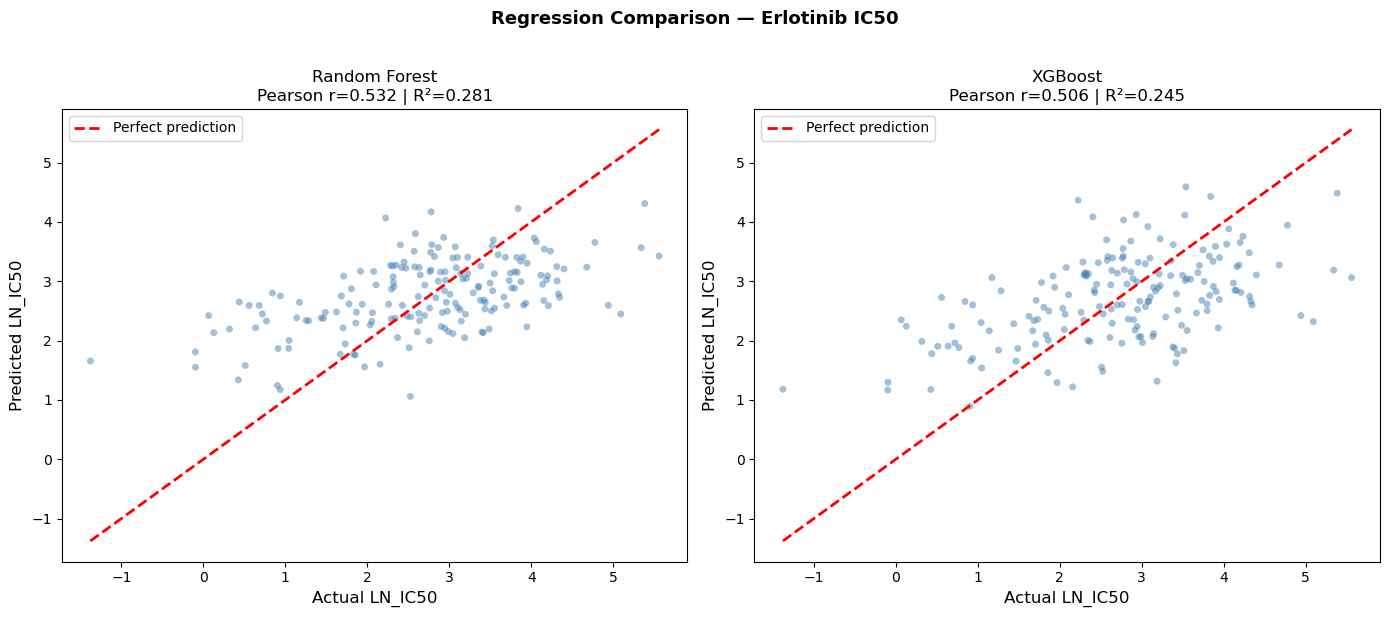

Plot 10 saved.


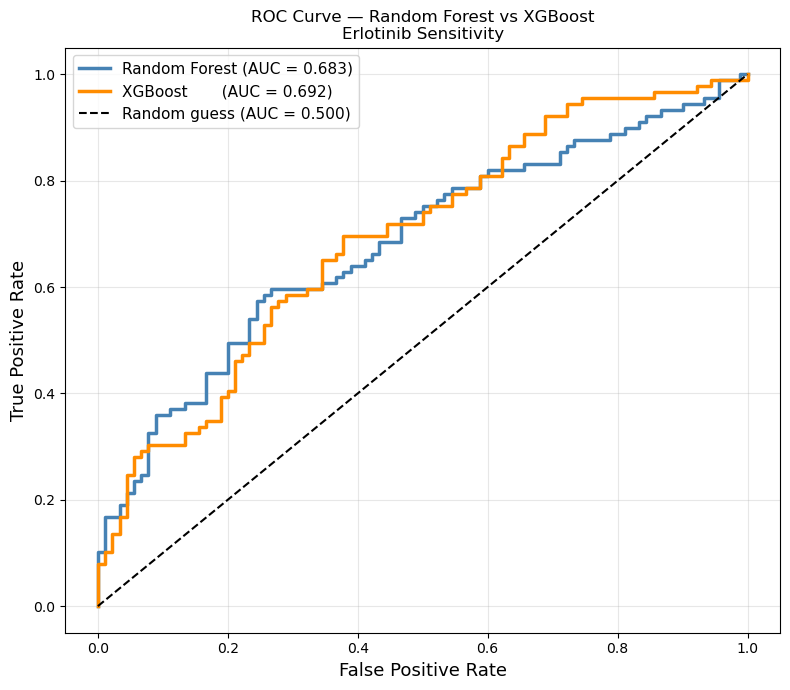

Plot 11 saved.


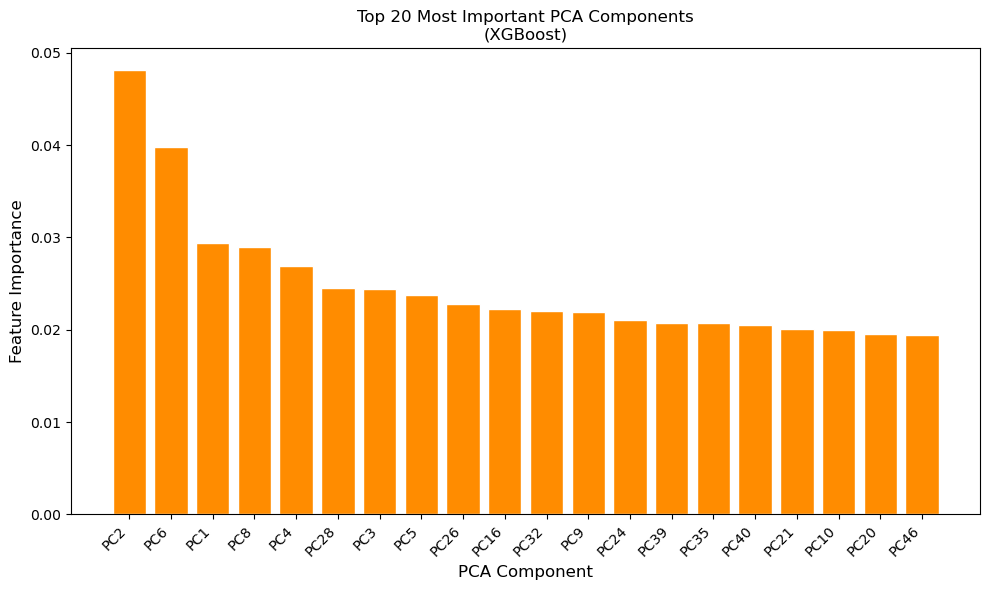

Plot 12 saved.

=== DAY 5 COMPLETE ===
             Model   RMSE     R2  Pearson_r  Accuracy  AUC_ROC     F1
     RF Regression 1.0070 0.2814     0.5317       NaN      NaN    NaN
 RF Classification    NaN    NaN        NaN    0.6201   0.6825 0.6344
    XGB Regression 1.0321 0.2452     0.5059       NaN      NaN    NaN
XGB Classification    NaN    NaN        NaN    0.6536   0.6918 0.6630


In [4]:
# ── XGBoost Regressor ────────────────────────────────────────────
print("Training XGBoost Regressor...")
xgb_reg = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    n_jobs=-1, random_state=42, verbosity=0
)
xgb_reg.fit(X_train, y_train_reg, verbose=False)
y_pred_xgb_reg       = xgb_reg.predict(X_test)
rmse_xgb             = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg))
r2_xgb               = r2_score(y_test_reg, y_pred_xgb_reg)
pearson_r_xgb, _     = pearsonr(y_test_reg, y_pred_xgb_reg)

print(f"RMSE:      {rmse_xgb:.4f}  (RF was 1.0070)")
print(f"R²:        {r2_xgb:.4f}  (RF was 0.2814)")
print(f"Pearson r: {pearson_r_xgb:.4f}  (RF was 0.5317)")

# ── XGBoost Classifier ───────────────────────────────────────────
print("\nTraining XGBoost Classifier...")
xgb_clf = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='logloss', n_jobs=-1,
    random_state=42, verbosity=0
)
xgb_clf.fit(X_train, y_train_clf, verbose=False)
y_pred_xgb_clf  = xgb_clf.predict(X_test)
y_pred_xgb_prob = xgb_clf.predict_proba(X_test)[:, 1]
acc_xgb  = accuracy_score(y_test_clf, y_pred_xgb_clf)
auc_xgb  = roc_auc_score(y_test_clf, y_pred_xgb_prob)
f1_xgb   = f1_score(y_test_clf, y_pred_xgb_clf)

print(f"Accuracy:  {acc_xgb*100:.1f}%  (RF was 62.0%)")
print(f"AUC-ROC:   {auc_xgb:.4f}  (RF was 0.6825)")
print(f"F1:        {f1_xgb:.4f}  (RF was 0.6344)")
print(classification_report(y_test_clf, y_pred_xgb_clf,
                             target_names=['Resistant','Sensitive']))

# ── Plot 10: Regression comparison ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, y_pred, title, r, r2 in zip(
    axes,
    [y_pred_rf_reg, y_pred_xgb_reg],
    ['Random Forest', 'XGBoost'],
    [0.5317, pearson_r_xgb],
    [0.2814, r2_xgb]
):
    ax.scatter(y_test_reg, y_pred, alpha=0.5, s=25,
               color='steelblue', edgecolors='none')
    mn = min(y_test_reg.min(), y_pred.min())
    mx = max(y_test_reg.max(), y_pred.max())
    ax.plot([mn,mx],[mn,mx],'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Actual LN_IC50', fontsize=12)
    ax.set_ylabel('Predicted LN_IC50', fontsize=12)
    ax.set_title(f'{title}\nPearson r={r:.3f} | R²={r2:.3f}', fontsize=12)
    ax.legend(fontsize=10)
plt.suptitle('Regression Comparison — Erlotinib IC50',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/plot10_xgb_vs_rf_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 10 saved.")

# ── Plot 11: ROC comparison ───────────────────────────────────────
fpr_rf,  tpr_rf,  _ = roc_curve(y_test_clf, y_pred_rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_clf, y_pred_xgb_prob)
plt.figure(figsize=(8, 7))
plt.plot(fpr_rf,  tpr_rf,  color='steelblue',  linewidth=2.5,
         label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', linewidth=2.5,
         label=f'XGBoost       (AUC = {auc_xgb:.3f})')
plt.plot([0,1],[0,1],'k--', linewidth=1.5, label='Random guess (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve — Random Forest vs XGBoost\nErlotinib Sensitivity', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/plot11_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 11 saved.")

# ── Plot 12: XGBoost feature importance ──────────────────────────
importances = xgb_clf.feature_importances_
indices     = np.argsort(importances)[::-1][:20]
plt.figure(figsize=(10, 6))
plt.bar(range(20), importances[indices],
        color='darkorange', edgecolor='white')
plt.xticks(range(20),
           [f'PC{indices[i]+1}' for i in range(20)],
           rotation=45, ha='right')
plt.xlabel('PCA Component', fontsize=12)
plt.ylabel('Feature Importance', fontsize=12)
plt.title('Top 20 Most Important PCA Components\n(XGBoost)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/plot12_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 12 saved.")

# ── Save models + update results table ───────────────────────────
joblib.dump(xgb_reg, 'models/xgb_regressor.pkl')
joblib.dump(xgb_clf, 'models/xgb_classifier.pkl')

new_rows = pd.DataFrame({
    'Model':     ['XGB Regression', 'XGB Classification'],
    'RMSE':      [round(rmse_xgb, 4),       None],
    'R2':        [round(r2_xgb, 4),         None],
    'Pearson_r': [round(pearson_r_xgb, 4),  None],
    'Accuracy':  [None, round(acc_xgb, 4)],
    'AUC_ROC':   [None, round(auc_xgb, 4)],
    'F1':        [None, round(f1_xgb, 4)]
})
results_df = pd.read_csv('models/model_results.csv')
results_df = pd.concat([results_df, new_rows], ignore_index=True)
results_df.to_csv('models/model_results.csv', index=False)

print("\n=== DAY 5 COMPLETE ===")
print(results_df.to_string(index=False))

In [5]:
import os
os.chdir(r'D:\DrugResponseProject')
print("Working directory:", os.getcwd())

Working directory: D:\DrugResponseProject


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, roc_auc_score,
                             f1_score, classification_report,
                             roc_curve)
from scipy.stats import pearsonr

X_train     = np.load('models/X_train.npy')
X_test      = np.load('models/X_test.npy')
y_train_reg = np.load('models/y_train_reg.npy')
y_test_reg  = np.load('models/y_test_reg.npy')
y_train_clf = np.load('models/y_train_clf.npy')
y_test_clf  = np.load('models/y_test_clf.npy')

# Load previous models for comparison plot
rf_clf  = joblib.load('models/rf_classifier.pkl')
xgb_clf = joblib.load('models/xgb_classifier.pkl')

rf_prob  = rf_clf.predict_proba(X_test)[:, 1]
xgb_prob = xgb_clf.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score, roc_curve
rf_auc  = roc_auc_score(y_test_clf, rf_prob)
xgb_auc = roc_auc_score(y_test_clf, xgb_prob)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test_clf, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_clf, xgb_prob)

print("X_train:", X_train.shape)
print("All loaded. Ready.")

X_train: (712, 50)
All loaded. Ready.
